In [19]:
"""
Refined Data Cleaning and Merging Script
Cleans CompustatNov and CRSPNov data and merges them based on CUSIP and date.
Outputs cleaned dataset with specific requested variables.
"""

import pandas as pd
import numpy as np
from pathlib import Path

# Set data directory
DATA_DIR = Path("/Users/owenbrown/Desktop/PythonFolder/FIN342/FinalProject_Dividend_ShareBuyBack")

print("Loading data files...")
print(f"CompustatNov.csv: {DATA_DIR / 'CompusstatNov.csv'}")
print(f"CRSPNov.csv: {DATA_DIR / 'CSRPNov.csv'}")

# Load Compustat data
comp = pd.read_csv(
    DATA_DIR / "CompusstatNov.csv",
    parse_dates=["datadate"],
    low_memory=False
)

# Load CRSP data
crsp = pd.read_csv(
    DATA_DIR / "CSRPNov.csv",
    parse_dates=["date"],
    low_memory=False
)

print(f"\nCompustat rows: {len(comp):,}")
print(f"CRSP rows: {len(crsp):,}")

# Display column names
print("\nCompustat columns:", comp.columns.tolist())
print("CRSP columns:", crsp.columns.tolist())


Loading data files...
CompustatNov.csv: /Users/owenbrown/Desktop/PythonFolder/FIN342/FinalProject_Dividend_ShareBuyBack/CompusstatNov.csv
CRSPNov.csv: /Users/owenbrown/Desktop/PythonFolder/FIN342/FinalProject_Dividend_ShareBuyBack/CSRPNov.csv

Compustat rows: 517,817
CRSP rows: 3,903,923

Compustat columns: ['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate', 'gvkey', 'cusip', 'sic', 'at', 'dvc', 'ni', 'prstkc']
CRSP columns: ['PERMNO', 'date', 'CUSIP', 'PRC', 'SHROUT', 'sprtrn']


In [20]:
"""
Step 1: Clean Compustat Data
- Trim CUSIP to 8 digits
- Convert date to monthly period-end
- Prepare buyback and dividend amounts
- Calculate return on assets (ROA)
"""

# Clean Compustat data
comp_clean = comp.copy()

# Trim CUSIP to 8 digits
comp_clean["cusip8"] = comp_clean["cusip"].astype(str).str.strip().str.slice(0, 8)

# Convert date to monthly period-end
comp_clean["month"] = comp_clean["datadate"].dt.to_period("M").dt.to_timestamp("M")

# Prepare buyback amount (prstkc is negative in Compustat, make it positive)
# Use abs() to ensure it's always positive regardless of sign
comp_clean["buyback"] = comp_clean["prstkc"].fillna(0.0).abs()

# Prepare dividend amount - ensure it's never negative
# Replace any negative values with 0
comp_clean["dividends"] = comp_clean["dvc"].fillna(0.0)
comp_clean["dividends"] = comp_clean["dividends"].clip(lower=0.0)

# Calculate Return on Assets (ROA) = ni / at
comp_clean["roa"] = comp_clean["ni"] / comp_clean["at"].replace(0, np.nan)

# Select relevant columns from Compustat
comp_final = comp_clean[[
    "cusip8",
    "month",
    "buyback",
    "dividends",
    "sic",
    "ni",  # net income
    "at",  # total assets (for ROA calculation)
    "roa"
]].copy()

print(f"Compustat cleaned rows: {len(comp_final):,}")
print(f"Unique CUSIPs: {comp_final['cusip8'].nunique():,}")
print(f"Date range: {comp_final['month'].min()} to {comp_final['month'].max()}")

# Display sample
print("\nSample Compustat data:")
display(comp_final.head(10))


Compustat cleaned rows: 517,817
Unique CUSIPs: 42,489
Date range: 1982-01-31 00:00:00 to 2024-12-31 00:00:00

Sample Compustat data:


,cusip8,month,buyback,dividends,sic,ni,at,roa
0,00016510,1982-12-31,0.000,0.0,5812,NaN,NaN,NaN
1,00035410,1983-12-31,1.200,0.0,5712,1.050,8.529,0.123109
2,00016510,1983-12-31,0.000,0.0,5812,1.135,14.080,0.080611
3,00016510,1984-12-31,0.000,0.0,5812,1.138,16.267,0.069958
4,00016510,1985-12-31,0.009,0.0,5812,2.576,39.495,0.065223
5,00035410,1982-12-31,0.000,0.0,5712,0.929,5.632,0.164950
6,00035410,1984-12-31,0.000,0.0,5712,0.387,8.241,0.046960
7,00035410,1986-01-31,0.000,0.0,5712,0.236,13.990,0.016869
8,00035410,1987-01-31,0.000,0.0,5712,0.793,14.586,0.054367
9,00035410,1988-01-31,0.000,0.0,5712,0.186,16.042,0.011595


In [21]:
"""
Step 2: Clean CRSP Data
- Trim CUSIP to 8 digits
- Convert date to monthly period-end
- Calculate market cap = PRC * SHROUT
- Prepare for merging
"""

# Clean CRSP data
crsp_clean = crsp.copy()

# Trim CUSIP to 8 digits
crsp_clean["cusip8"] = crsp_clean["CUSIP"].astype(str).str.strip().str.slice(0, 8)

# Convert date to monthly period-end
crsp_clean["month"] = crsp_clean["date"].dt.to_period("M").dt.to_timestamp("M")

# Ensure PRC and SHROUT are numeric
crsp_clean["PRC"] = pd.to_numeric(crsp_clean["PRC"], errors="coerce")
crsp_clean["SHROUT"] = pd.to_numeric(crsp_clean["SHROUT"], errors="coerce")

# Make PRC positive (use absolute value - negative prices in CRSP indicate bid prices)
# We want absolute price values for analysis
crsp_clean["PRC"] = crsp_clean["PRC"].abs()

# Calculate market cap = PRC * SHROUT (in thousands, so multiply by 1000)
# PRC is price, SHROUT is shares outstanding in thousands
crsp_clean["market_cap"] = crsp_clean["PRC"] * crsp_clean["SHROUT"] * 1000

# Ensure sprtrn is numeric (equity return)
crsp_clean["sprtrn"] = pd.to_numeric(crsp_clean["sprtrn"], errors="coerce")

# Select relevant columns from CRSP
crsp_final = crsp_clean[[
    "PERMNO",
    "cusip8",
    "month",
    "PRC",
    "market_cap",
    "sprtrn"
]].copy()

# Sort by PERMNO and month for forward return calculations
crsp_final = crsp_final.sort_values(["PERMNO", "month"]).reset_index(drop=True)

print(f"CRSP cleaned rows: {len(crsp_final):,}")
print(f"Unique CUSIPs: {crsp_final['cusip8'].nunique():,}")
print(f"Unique PERMNOs: {crsp_final['PERMNO'].nunique():,}")
print(f"Date range: {crsp_final['month'].min()} to {crsp_final['month'].max()}")

# Display sample
print("\nSample CRSP data:")
display(crsp_final.head(10))


CRSP cleaned rows: 3,903,923
Unique CUSIPs: 34,860
Unique PERMNOs: 34,860
Date range: 1982-01-31 00:00:00 to 2024-12-31 00:00:00

Sample CRSP data:


,PERMNO,cusip8,month,PRC,market_cap,sprtrn
0,10000,68391610,1985-12-31,NaN,NaN,0.045061
1,10000,68391610,1986-01-31,4.37500,16100000.00,0.002367
2,10000,68391610,1986-02-28,3.25000,11960000.00,0.071489
3,10000,68391610,1986-03-31,4.43750,16330000.00,0.052794
4,10000,68391610,1986-04-30,4.00000,15172000.00,-0.014148
5,10000,68391610,1986-05-31,3.10938,11793878.34,0.050229
6,10000,68391610,1986-06-30,3.09375,11734593.75,0.014110
7,10000,68391610,1986-07-31,2.84375,10786343.75,-0.058683
8,10000,68391610,1986-08-31,1.09375,4148593.75,0.071193
9,10000,68391610,1986-09-30,1.03125,3911531.25,-0.085439


In [22]:
"""
Step 3: Calculate Forward Returns (1y, 2y, 5y)
Using sprtrn (equity return) from CRSP data
"""

def forward_buy_and_hold(df, return_col, horizon):
    """
    Computes the compound return from t+1 through t+horizon for each PERMNO.
    Uses log returns to handle negative values properly.
    
    Parameters:
    -----------
    df : DataFrame
        Data sorted by PERMNO and month
    return_col : str
        Column name for returns
    horizon : int
        Number of months for forward return
    
    Returns:
    --------
    Series with forward returns
    """
    def _calc(series):
        # Convert to log returns
        log_r = np.log1p(series)
        # Start from next month (t+1) and roll forward
        fwd_log = (
            log_r.shift(-1)  # Start at next month
            .rolling(window=horizon, min_periods=horizon)
            .sum()
            .shift(-(horizon - 1))  # Align back to current month
        )
        # Convert back to simple returns
        return np.expm1(fwd_log)
    
    return (
        df.groupby("PERMNO", group_keys=False)[return_col]
        .apply(_calc)
    )

# Calculate forward returns
print("Calculating forward returns...")
crsp_final["ret_1y"] = forward_buy_and_hold(crsp_final, "sprtrn", 12)
crsp_final["ret_2y"] = forward_buy_and_hold(crsp_final, "sprtrn", 24)
crsp_final["ret_5y"] = forward_buy_and_hold(crsp_final, "sprtrn", 60)

print(f"Rows with 1y return: {crsp_final['ret_1y'].notna().sum():,}")
print(f"Rows with 2y return: {crsp_final['ret_2y'].notna().sum():,}")
print(f"Rows with 5y return: {crsp_final['ret_5y'].notna().sum():,}")

# Display sample
print("\nSample CRSP data with forward returns:")
display(crsp_final[["PERMNO", "cusip8", "month", "sprtrn", "ret_1y", "ret_2y", "ret_5y"]].head(10))


Calculating forward returns...
Rows with 1y return: 3,495,203
Rows with 2y return: 3,120,153
Rows with 5y return: 2,254,170

Sample CRSP data with forward returns:


,PERMNO,cusip8,month,sprtrn,ret_1y,ret_2y,ret_5y
0,10000,68391610,1985-12-31,0.045061,0.146204,NaN,NaN
1,10000,68391610,1986-01-31,0.002367,0.294173,NaN,NaN
2,10000,68391610,1986-02-28,0.071489,0.252424,NaN,NaN
3,10000,68391610,1986-03-31,0.052794,0.221014,NaN,NaN
4,10000,68391610,1986-04-30,-0.014148,0.224355,NaN,NaN
5,10000,68391610,1986-05-31,0.050229,0.172833,NaN,NaN
6,10000,68391610,1986-06-30,0.014110,0.211929,NaN,NaN
7,10000,68391610,1986-07-31,-0.058683,NaN,NaN,NaN
8,10000,68391610,1986-08-31,0.071193,NaN,NaN,NaN
9,10000,68391610,1986-09-30,-0.085439,NaN,NaN,NaN


In [23]:
"""
Step 4: Merge Compustat and CRSP data
Merge on CUSIP (8 digits) and month
"""

# Merge Compustat and CRSP
merged = pd.merge(
    comp_final,
    crsp_final,
    on=["cusip8", "month"],
    how="inner",
    suffixes=("_comp", "_crsp")
)

print(f"Merged rows: {len(merged):,}")
print(f"Merge rate: {len(merged) / len(comp_final) * 100:.1f}% of Compustat rows")
print(f"Unique CUSIPs after merge: {merged['cusip8'].nunique():,}")
print(f"Date range: {merged['month'].min()} to {merged['month'].max()}")

# Check for duplicates
dup_check = merged.groupby(["cusip8", "month"]).size()
dup_count = (dup_check > 1).sum()
print(f"\nDuplicate CUSIP-month pairs: {dup_count}")

if dup_count > 0:
    print("\nSample duplicates:")
    display(dup_check[dup_check > 1].head(10))

# Ensure buybacks, dividends, and PRC are non-negative (safety check)
# Clip any negative values to 0 for buybacks and dividends
merged["buyback"] = merged["buyback"].clip(lower=0.0)
merged["dividends"] = merged["dividends"].clip(lower=0.0)

# Ensure PRC is positive (use absolute value)
merged["PRC"] = merged["PRC"].abs()

# Report any issues
negative_buyback = (merged["buyback"] < 0).sum()
negative_dividends = (merged["dividends"] < 0).sum()
negative_prc = (merged["PRC"] < 0).sum()

issues = []
if negative_buyback > 0:
    issues.append(f"{negative_buyback} negative buyback values")
if negative_dividends > 0:
    issues.append(f"{negative_dividends} negative dividend values")
if negative_prc > 0:
    issues.append(f"{negative_prc} negative PRC values")

if issues:
    print(f"\nWARNING: Found {', '.join(issues)}")
    print("These have been corrected (clipped to 0 or made positive).")
else:
    print(f"\n✓ Validation: All buyback, dividend, and PRC values are non-negative")

# Display sample
print("\nSample merged data:")
display(merged.head(10))


Merged rows: 310,888
Merge rate: 60.0% of Compustat rows
Unique CUSIPs after merge: 28,151
Date range: 1982-01-31 00:00:00 to 2024-12-31 00:00:00

Duplicate CUSIP-month pairs: 34362

Sample duplicates:


cusip8    month     
00086810  2010-12-31    2
          2011-12-31    2
          2012-12-31    2
          2013-12-31    2
          2014-12-31    2
          2015-12-31    2
          2016-12-31    2
          2017-12-31    2
          2018-12-31    2
          2019-12-31    2
dtype: int64


✓ Validation: All buyback, dividend, and PRC values are non-negative

Sample merged data:


,cusip8,month,buyback,dividends,sic,ni,at,roa,PERMNO,PRC,market_cap,sprtrn,ret_1y,ret_2y,ret_5y
0,00035410,1983-12-31,1.200,0.000,5712,1.050,8.529,0.123109,10031,5.3750,14421125.0,-0.008834,0.014007,0.281030,0.683871
1,00016510,1983-12-31,0.000,0.000,5812,1.135,14.080,0.080611,10015,7.5000,26775000.0,-0.008834,0.014007,0.281030,NaN
2,00016510,1984-12-31,0.000,0.000,5812,1.138,16.267,0.069958,10015,3.8125,13610625.0,0.022374,0.263334,NaN,NaN
3,00016510,1985-12-31,0.009,0.000,5812,2.576,39.495,0.065223,10015,10.1250,40378500.0,0.045061,NaN,NaN,NaN
4,00035410,1984-12-31,0.000,0.000,5712,0.387,8.241,0.046960,10031,3.0000,8049000.0,0.022374,0.263334,0.448039,NaN
5,00035410,1986-01-31,0.000,0.000,5712,0.236,13.990,0.016869,10031,4.7500,12744250.0,0.002367,0.294173,0.213855,NaN
6,00035410,1987-01-31,0.000,0.000,5712,0.793,14.586,0.054367,10031,4.6875,12576562.5,0.131767,-0.062061,0.085342,NaN
7,00035410,1988-01-31,0.000,0.000,5712,0.186,16.042,0.011595,10031,3.1250,8384375.0,0.040432,0.157156,NaN,NaN
8,00035410,1989-01-31,0.000,0.000,5712,-7.838,16.280,-0.481450,10031,2.0000,5366000.0,0.071115,NaN,NaN,NaN
9,00036110,1982-05-31,0.518,1.582,5080,1.225,113.653,0.010778,54594,7.0000,27594000.0,-0.039162,0.451465,0.345640,1.592963


In [24]:
"""
Step 5: Classify Companies by Payout Type
Classify each observation as:
- "buyback": Company is buyback-dominant (>= threshold % of total payouts from buybacks)
- "dividend": Company is dividend-dominant (>= threshold % of total payouts from dividends)
- "mixed": Company uses both buybacks and dividends roughly equally
- "no_payout": Company has no meaningful payouts (total <= 0 or below minimum threshold)
"""

# Configuration parameters (can be adjusted)
DOMINANCE_THRESHOLD = 0.70  # % of total payouts that must come from one channel to be "dominant"
MIN_TOTAL_PAYOUT = 0  # Minimum total payout in dollars (can be adjusted or set to 0)

# Calculate total payouts
merged["total_payouts"] = merged["buyback"] + merged["dividends"]

# Calculate payout shares (proportion of total payouts from each source)
# Avoid division by zero for cases with no payouts
merged["buyback_share"] = np.where(
    merged["total_payouts"] > 0,
    merged["buyback"] / merged["total_payouts"],
    np.nan
)
merged["dividend_share"] = np.where(
    merged["total_payouts"] > 0,
    merged["dividends"] / merged["total_payouts"],
    np.nan
)

# Classify payout type
def classify_payout_type(row):
    """
    Classify company based on buyback and dividend amounts.
    
    Returns:
    --------
    str: One of "buyback", "dividend", "mixed", or "no_payout"
    """
    total_payouts = row["total_payouts"]
    
    # Check if no payouts or below minimum threshold
    if total_payouts <= 0 or total_payouts < MIN_TOTAL_PAYOUT:
        return "no_payout"
    
    buyback_share = row["buyback_share"]
    dividend_share = row["dividend_share"]
    
    # Check for dominance
    if buyback_share >= DOMINANCE_THRESHOLD:
        return "buyback"
    elif dividend_share >= DOMINANCE_THRESHOLD:
        return "dividend"
    else:
        # Neither is dominant - classify as mixed
        return "mixed"

# Apply classification
merged["payout_type"] = merged.apply(classify_payout_type, axis=1)

# Summary statistics
print("Payout Type Classification Summary:")
print("=" * 50)
payout_counts = merged["payout_type"].value_counts()
print(payout_counts)
print(f"\nPercentages:")
print(payout_counts / len(merged) * 100)

# Display sample
print("\nSample classified data:")
display(merged[["cusip8", "month", "buyback", "dividends", "total_payouts", 
                "buyback_share", "dividend_share", "payout_type"]].head(20))

# Show examples of each type
print("\nExamples of each payout type:")
for ptype in ["buyback", "dividend", "mixed", "no_payout"]:
    sample = merged[merged["payout_type"] == ptype].head(3)
    if len(sample) > 0:
        print(f"\n{ptype.upper()} examples:")
        display(sample[["cusip8", "month", "buyback", "dividends", "total_payouts", 
                        "buyback_share", "dividend_share", "payout_type"]])


Payout Type Classification Summary:
payout_type
no_payout    154376
dividend      90851
buyback       49906
mixed         15755
Name: count, dtype: int64

Percentages:
payout_type
no_payout    49.656468
dividend     29.223064
buyback      16.052726
mixed         5.067741
Name: count, dtype: float64

Sample classified data:


,cusip8,month,buyback,dividends,total_payouts,buyback_share,dividend_share,payout_type
0,00035410,1983-12-31,1.200,0.000,1.200,1.000000,0.000000,buyback
1,00016510,1983-12-31,0.000,0.000,0.000,NaN,NaN,no_payout
2,00016510,1984-12-31,0.000,0.000,0.000,NaN,NaN,no_payout
3,00016510,1985-12-31,0.009,0.000,0.009,1.000000,0.000000,buyback
4,00035410,1984-12-31,0.000,0.000,0.000,NaN,NaN,no_payout
5,00035410,1986-01-31,0.000,0.000,0.000,NaN,NaN,no_payout
6,00035410,1987-01-31,0.000,0.000,0.000,NaN,NaN,no_payout
7,00035410,1988-01-31,0.000,0.000,0.000,NaN,NaN,no_payout
8,00035410,1989-01-31,0.000,0.000,0.000,NaN,NaN,no_payout
9,00036110,1982-05-31,0.518,1.582,2.100,0.246667,0.753333,dividend



Examples of each payout type:

BUYBACK examples:


,cusip8,month,buyback,dividends,total_payouts,buyback_share,dividend_share,payout_type
0,00035410,1983-12-31,1.200,0.0,1.200,1.0,0.0,buyback
3,00016510,1985-12-31,0.009,0.0,0.009,1.0,0.0,buyback
28,00087230,1987-12-31,0.004,0.0,0.004,1.0,0.0,buyback



DIVIDEND examples:


,cusip8,month,buyback,dividends,total_payouts,buyback_share,dividend_share,payout_type
9,00036110,1982-05-31,0.518,1.582,2.100,0.246667,0.753333,dividend
10,00036110,1983-05-31,0.211,1.727,1.938,0.108875,0.891125,dividend
11,00036110,1984-05-31,0.003,1.965,1.968,0.001524,0.998476,dividend



MIXED examples:


,cusip8,month,buyback,dividends,total_payouts,buyback_share,dividend_share,payout_type
25,00036110,1997-05-31,8.080,7.976,16.056,0.503239,0.496761,mixed
27,00036110,1999-05-31,7.558,9.375,16.933,0.446347,0.553653,mixed
29,00036110,2000-05-31,10.530,9.218,19.748,0.533219,0.466781,mixed



NO_PAYOUT examples:


,cusip8,month,buyback,dividends,total_payouts,buyback_share,dividend_share,payout_type
1,00016510,1983-12-31,0.0,0.0,0.0,NaN,NaN,no_payout
2,00016510,1984-12-31,0.0,0.0,0.0,NaN,NaN,no_payout
4,00035410,1984-12-31,0.0,0.0,0.0,NaN,NaN,no_payout


In [25]:
"""
Step 6: Select and organize final columns
Keep only the requested variables:
- CUSIP (cusip8)
- PRC
- market_cap
- ret_1y, ret_2y, ret_5y
- buyback
- dividends
- sic
- ni (net income)
- roa (return on assets)
- sprtrn (equity return)
- payout_type (classification: buyback, dividend, mixed, or no_payout)
Note: month is included for time-series analysis but can be removed if not needed
"""

# Select final columns in requested order (including month for time-series analysis)
final_data = merged[[
    "cusip8",
    "month",
    "PRC",
    "market_cap",
    "ret_1y",
    "ret_2y",
    "ret_5y",
    "buyback",
    "dividends",
    "sic",
    "ni",
    "roa",
    "sprtrn",
    "payout_type"  # Add payout classification
]].copy()

# Rename cusip8 to CUSIP for consistency
final_data = final_data.rename(columns={"cusip8": "CUSIP"})

# Sort by CUSIP and month
final_data = final_data.sort_values(["CUSIP", "month"]).reset_index(drop=True)

print(f"Final dataset shape: {final_data.shape}")
print(f"\nFinal columns:")
print(final_data.columns.tolist())

print(f"\nData summary:")
print(f"Total rows: {len(final_data):,}")
print(f"Unique CUSIPs: {final_data['CUSIP'].nunique():,}")
print(f"Date range: {final_data['month'].min()} to {final_data['month'].max()}")
print(f"\nMissing values:")
display(final_data.isnull().sum())

# Display sample
print("\nSample final data:")
display(final_data.head(20))

# Display summary statistics
print("\nSummary statistics:")
display(final_data.describe())


Final dataset shape: (310888, 14)

Final columns:
['CUSIP', 'month', 'PRC', 'market_cap', 'ret_1y', 'ret_2y', 'ret_5y', 'buyback', 'dividends', 'sic', 'ni', 'roa', 'sprtrn', 'payout_type']

Data summary:
Total rows: 310,888
Unique CUSIPs: 28,151
Date range: 1982-01-31 00:00:00 to 2024-12-31 00:00:00

Missing values:


CUSIP               0
month               0
PRC              5097
market_cap       5097
ret_1y          25305
ret_2y          54003
ret_5y         122712
buyback             0
dividends           0
sic                 0
ni              88555
roa             88680
sprtrn              0
payout_type         0
dtype: int64


Sample final data:


,CUSIP,month,PRC,market_cap,ret_1y,ret_2y,ret_5y,buyback,dividends,sic,ni,roa,sprtrn,payout_type
0,00002130,1991-06-30,5.12500,32641125.0,0.099633,0.213842,0.806849,0.000,0.000,2020,-0.326,-0.034889,-0.047893,no_payout
1,00002130,1992-06-30,2.50000,19285000.0,0.103861,0.088524,1.168722,0.000,0.000,2020,-1.860,-0.102400,-0.017359,no_payout
2,00002130,1993-06-30,2.31250,18261812.5,-0.013894,0.209131,NaN,0.000,0.000,2020,-0.469,-0.024775,0.000755,no_payout
3,00002130,1994-06-30,0.93750,7923750.0,0.226168,0.509511,NaN,0.000,0.000,2020,-2.209,-0.115921,-0.026812,no_payout
4,00002130,1995-06-30,0.59375,5018375.0,0.231080,0.624860,NaN,0.000,0.000,2020,-1.353,-0.070968,0.021279,no_payout
5,00002130,1996-06-30,0.68750,5810750.0,0.319866,NaN,NaN,0.000,0.000,2020,-2.285,-0.124557,0.002257,no_payout
6,00002130,1997-06-30,0.21875,1848875.0,NaN,NaN,NaN,0.000,0.000,2020,-3.977,-0.284498,0.043453,no_payout
7,00016510,1983-12-31,7.50000,26775000.0,0.014007,0.281030,NaN,0.000,0.000,5812,1.135,0.080611,-0.008834,no_payout
8,00016510,1984-12-31,3.81250,13610625.0,0.263334,NaN,NaN,0.000,0.000,5812,1.138,0.069958,0.022374,no_payout
9,00016510,1985-12-31,10.12500,40378500.0,NaN,NaN,NaN,0.009,0.000,5812,2.576,0.065223,0.045061,buyback



Summary statistics:


,month,PRC,market_cap,ret_1y,ret_2y,ret_5y,buyback,dividends,sic,ni,roa,sprtrn
count,310888,305791.000000,3.057910e+05,285583.000000,256885.000000,188176.000000,310888.000000,310888.000000,310888.000000,222333.000000,222208.000000,310888.000000
mean,2005-04-21 07:10:36.792671104,26.741788,2.998779e+09,0.107056,0.217326,0.602151,60.748392,70.689748,5271.308159,178.396482,-0.076808,0.010231
min,1982-01-31 00:00:00,0.030000,5.031320e+03,-0.447561,-0.477479,-0.357965,0.000000,0.000000,100.000000,-99289.000000,-1719.000000,-0.217630
25%,1995-01-31 00:00:00,7.000000,4.079342e+07,0.014007,0.087391,0.235365,0.000000,0.000000,3672.000000,-2.441000,-0.036007,-0.008628
50%,2004-12-31 00:00:00,15.860000,1.826250e+08,0.127828,0.189043,0.668932,0.000000,0.000000,6020.000000,4.238000,0.018043,0.012299
75%,2015-12-31 00:00:00,30.437500,9.083374e+08,0.234799,0.430307,0.866151,0.070000,5.332000,6722.000000,44.641000,0.063216,0.034637
max,2024-12-31 00:00:00,8178.899900,3.522211e+12,0.537143,0.805524,2.425361,100390.000000,67643.805000,9997.000000,100118.000000,390.720000,0.131767
std,NaN,66.754129,2.361040e+10,0.165703,0.251350,0.521720,788.029118,499.188638,1859.179817,1538.923986,4.444668,0.038832


In [26]:
"""
Step 7: Data Quality Checks and Final Cleanup
"""

# Data quality checks
print("Data Quality Checks:")
print("=" * 50)

# Check for negative market caps (should not happen)
negative_mcap = (final_data["market_cap"] < 0).sum()
print(f"Negative market caps: {negative_mcap}")

# Check for negative buybacks, dividends, and PRC (should not happen)
negative_buyback = (final_data["buyback"] < 0).sum()
negative_dividends = (final_data["dividends"] < 0).sum()
negative_prc = (final_data["PRC"] < 0).sum()
print(f"Negative buybacks: {negative_buyback}")
print(f"Negative dividends: {negative_dividends}")
print(f"Negative PRC: {negative_prc}")

# Final safeguard: ensure no negative values
final_data["buyback"] = final_data["buyback"].clip(lower=0.0)
final_data["dividends"] = final_data["dividends"].clip(lower=0.0)
final_data["PRC"] = final_data["PRC"].abs()  # Ensure PRC is always positive

# Check for extreme values
print(f"\nMarket cap range: ${final_data['market_cap'].min():,.0f} to ${final_data['market_cap'].max():,.0f}")
print(f"Net income range: ${final_data['ni'].min():,.0f} to ${final_data['ni'].max():,.0f}")

# Check date consistency
print(f"\nDate range: {final_data['month'].min()} to {final_data['month'].max()}")
print(f"Total months: {final_data['month'].nunique()}")

# Check CUSIP format
print(f"\nCUSIP length check:")
cusip_lengths = final_data["CUSIP"].str.len()
print(cusip_lengths.value_counts().sort_index())

# Payout type distribution
print(f"\nPayout type distribution:")
payout_dist = final_data["payout_type"].value_counts()
print(payout_dist)
print(f"\nPercentages:")
print(payout_dist / len(final_data) * 100)

# Final dataset info
print(f"\n{'='*50}")
print(f"FINAL CLEANED DATASET READY")
print(f"{'='*50}")
print(f"Shape: {final_data.shape}")
print(f"Columns: {list(final_data.columns)}")
print(f"\nFirst few rows:")
display(final_data.head(10))


Data Quality Checks:
Negative market caps: 0
Negative buybacks: 0
Negative dividends: 0
Negative PRC: 0

Market cap range: $5,031 to $3,522,211,138,000
Net income range: $-99,289 to $100,118

Date range: 1982-01-31 00:00:00 to 2024-12-31 00:00:00
Total months: 516

CUSIP length check:
CUSIP
8    310888
Name: count, dtype: int64

Payout type distribution:
payout_type
no_payout    154376
dividend      90851
buyback       49906
mixed         15755
Name: count, dtype: int64

Percentages:
payout_type
no_payout    49.656468
dividend     29.223064
buyback      16.052726
mixed         5.067741
Name: count, dtype: float64

FINAL CLEANED DATASET READY
Shape: (310888, 14)
Columns: ['CUSIP', 'month', 'PRC', 'market_cap', 'ret_1y', 'ret_2y', 'ret_5y', 'buyback', 'dividends', 'sic', 'ni', 'roa', 'sprtrn', 'payout_type']

First few rows:


,CUSIP,month,PRC,market_cap,ret_1y,ret_2y,ret_5y,buyback,dividends,sic,ni,roa,sprtrn,payout_type
0,00002130,1991-06-30,5.12500,32641125.0,0.099633,0.213842,0.806849,0.000,0.0,2020,-0.326,-0.034889,-0.047893,no_payout
1,00002130,1992-06-30,2.50000,19285000.0,0.103861,0.088524,1.168722,0.000,0.0,2020,-1.860,-0.102400,-0.017359,no_payout
2,00002130,1993-06-30,2.31250,18261812.5,-0.013894,0.209131,NaN,0.000,0.0,2020,-0.469,-0.024775,0.000755,no_payout
3,00002130,1994-06-30,0.93750,7923750.0,0.226168,0.509511,NaN,0.000,0.0,2020,-2.209,-0.115921,-0.026812,no_payout
4,00002130,1995-06-30,0.59375,5018375.0,0.231080,0.624860,NaN,0.000,0.0,2020,-1.353,-0.070968,0.021279,no_payout
5,00002130,1996-06-30,0.68750,5810750.0,0.319866,NaN,NaN,0.000,0.0,2020,-2.285,-0.124557,0.002257,no_payout
6,00002130,1997-06-30,0.21875,1848875.0,NaN,NaN,NaN,0.000,0.0,2020,-3.977,-0.284498,0.043453,no_payout
7,00016510,1983-12-31,7.50000,26775000.0,0.014007,0.281030,NaN,0.000,0.0,5812,1.135,0.080611,-0.008834,no_payout
8,00016510,1984-12-31,3.81250,13610625.0,0.263334,NaN,NaN,0.000,0.0,5812,1.138,0.069958,0.022374,no_payout
9,00016510,1985-12-31,10.12500,40378500.0,NaN,NaN,NaN,0.009,0.0,5812,2.576,0.065223,0.045061,buyback


PART 1: OVERALL SUMMARY STATISTICS BY PAYOUT TYPE

Total observations: 310,888
Date range: 1982-01 to 2024-12




,n_observations,n_firms,avg_market_cap_millions,avg_roa_pct,pct_of_total
payout_type,,,,,
buyback,49906,11521,4610.61,-2.100,16.05
dividend,90851,8675,3692.13,8.357,29.22
mixed,15755,4043,13185.99,5.647,5.07
no_payout,154376,23674,985.21,-24.622,49.66



FORMATTED SUMMARY BY PAYOUT TYPE (OVERALL)

BUYBACK:
  • Number of observations: 49,906.0 (16.1% of total)
  • Number of unique firms: 11,521.0
  • Average market cap: $4,610.61 million
  • Average ROA: -2.100%

DIVIDEND:
  • Number of observations: 90,851.0 (29.2% of total)
  • Number of unique firms: 8,675.0
  • Average market cap: $3,692.13 million
  • Average ROA: 8.357%

MIXED:
  • Number of observations: 15,755.0 (5.1% of total)
  • Number of unique firms: 4,043.0
  • Average market cap: $13,185.99 million
  • Average ROA: 5.647%

NO PAYOUT:
  • Number of observations: 154,376.0 (49.7% of total)
  • Number of unique firms: 23,674.0
  • Average market cap: $985.21 million
  • Average ROA: -24.622%

INDUSTRY BREAKDOWN BY PAYOUT TYPE (Number of Firms)

This table shows how many unique firms (by CUSIP) fall into each SIC industry category:



industry,"Agriculture, Forestry, And Fishing",Mining,Construction,Manufacturing,"Transportation, Communications, Electric, Gas, And Sanitary Services",Wholesale Trade,Retail Trade,"Finance, Insurance, And Real Estate",Services,Public Administration,Unknown
payout_type,,,,,,,,,,,
buyback,0,664,140,4387,792,388,717,1752,2585,96,0
dividend,0,457,98,2491,801,281,432,3123,950,42,0
mixed,0,184,41,1387,400,124,192,1309,392,14,0
no_payout,0,1106,206,6589,1153,562,993,9130,3664,271,0



INDUSTRY BREAKDOWN BY PAYOUT TYPE (Formatted)

BUYBACK - Firms by Industry:
  • Mining: 664 firms
  • Construction: 140 firms
  • Manufacturing: 4,387 firms
  • Transportation, Communications, Electric, Gas, And Sanitary Services: 792 firms
  • Wholesale Trade: 388 firms
  • Retail Trade: 717 firms
  • Finance, Insurance, And Real Estate: 1,752 firms
  • Services: 2,585 firms
  • Public Administration: 96 firms

DIVIDEND - Firms by Industry:
  • Mining: 457 firms
  • Construction: 98 firms
  • Manufacturing: 2,491 firms
  • Transportation, Communications, Electric, Gas, And Sanitary Services: 801 firms
  • Wholesale Trade: 281 firms
  • Retail Trade: 432 firms
  • Finance, Insurance, And Real Estate: 3,123 firms
  • Services: 950 firms
  • Public Administration: 42 firms

MIXED - Firms by Industry:
  • Mining: 184 firms
  • Construction: 41 firms
  • Manufacturing: 1,387 firms
  • Transportation, Communications, Electric, Gas, And Sanitary Services: 400 firms
  • Wholesale Trade: 124 

,payout_type,period,n_observations,n_firms,avg_market_cap_millions,avg_roa_pct,pct_of_total
0,buyback,1982-01,145,145,61.93,0.444,12.27
1,dividend,1982-01,424,421,142.70,8.228,35.87
2,mixed,1982-01,43,43,125.77,5.741,3.64
3,no_payout,1982-01,570,568,32.15,-8.347,48.22
4,buyback,1982-07,342,342,93.13,0.861,10.40
...,...,...,...,...,...,...,...
339,no_payout,2024-01,384,376,5485.95,-68.648,47.47
340,buyback,2024-07,1459,1459,14110.27,-8.905,16.58
341,dividend,2024-07,1643,1232,13081.40,5.692,18.67
342,mixed,2024-07,476,476,25879.76,5.008,5.41



FORMATTED TIME-SERIES SUMMARY (SAMPLE - EVERY 10 PERIODS)

PERIOD: 1982-01

BUYBACK:
  • Observations: 145 (12.3% of period)
  • Unique firms: 145
  • Avg market cap: $61.93M
  • Avg ROA: 0.444%

DIVIDEND:
  • Observations: 424 (35.9% of period)
  • Unique firms: 421
  • Avg market cap: $142.70M
  • Avg ROA: 8.228%

MIXED:
  • Observations: 43 (3.6% of period)
  • Unique firms: 43
  • Avg market cap: $125.77M
  • Avg ROA: 5.741%

NO PAYOUT:
  • Observations: 570 (48.2% of period)
  • Unique firms: 568
  • Avg market cap: $32.15M
  • Avg ROA: -8.347%

PERIOD: 1987-01

BUYBACK:
  • Observations: 244 (15.5% of period)
  • Unique firms: 244
  • Avg market cap: $170.38M
  • Avg ROA: -4.387%

DIVIDEND:
  • Observations: 317 (20.1% of period)
  • Unique firms: 312
  • Avg market cap: $523.73M
  • Avg ROA: 5.225%

MIXED:
  • Observations: 58 (3.7% of period)
  • Unique firms: 58
  • Avg market cap: $641.38M
  • Avg ROA: 5.364%

NO PAYOUT:
  • Observations: 955 (60.7% of period)
  • Unique fir

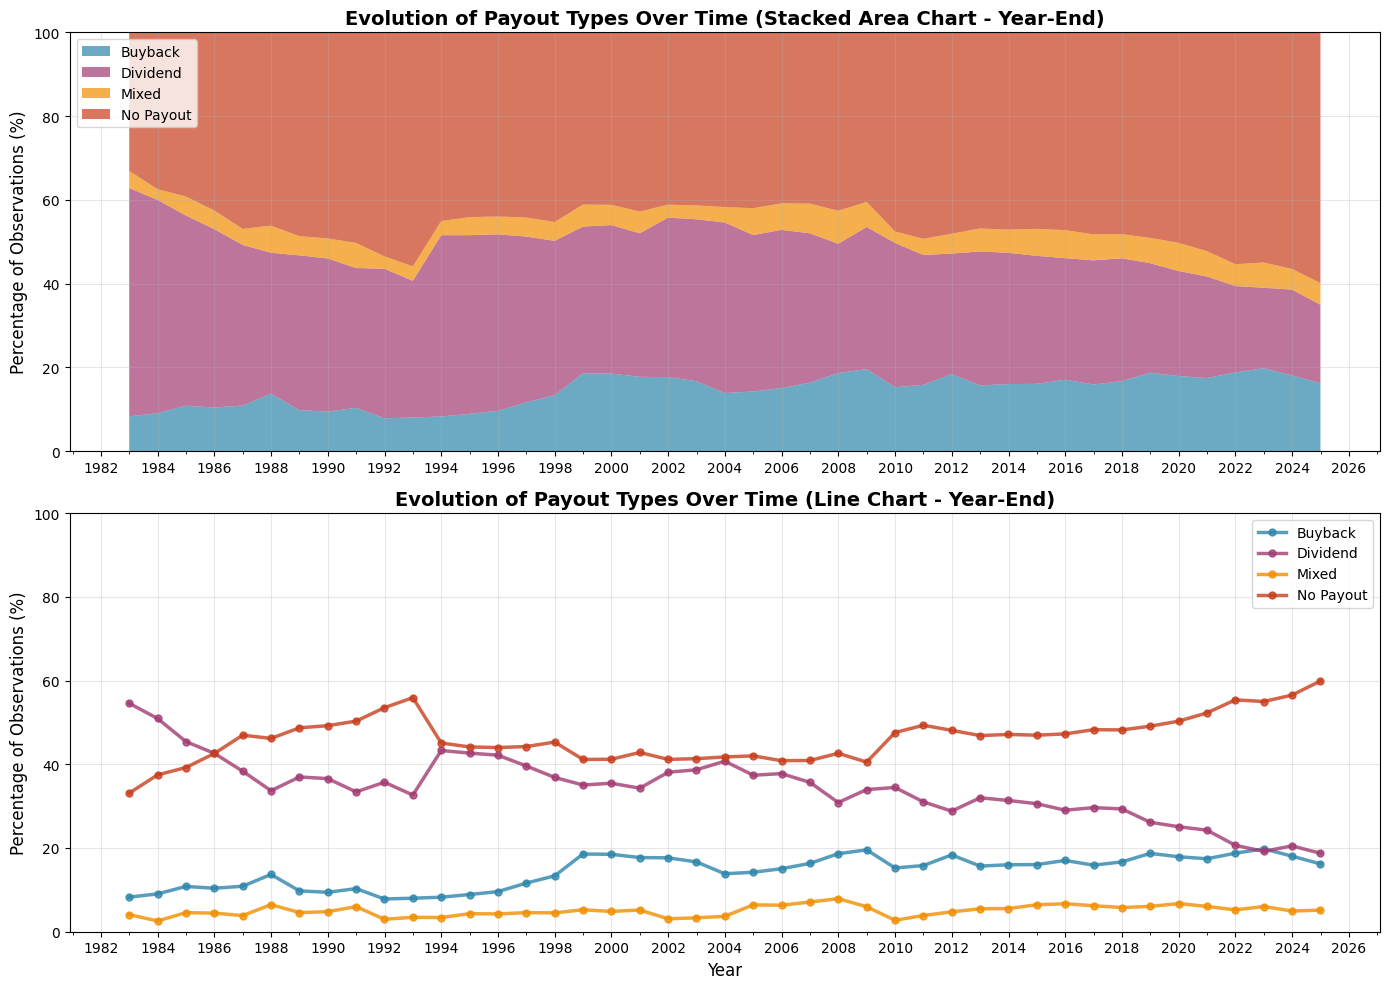


INDUSTRY EVOLUTION BY PAYOUT TYPE


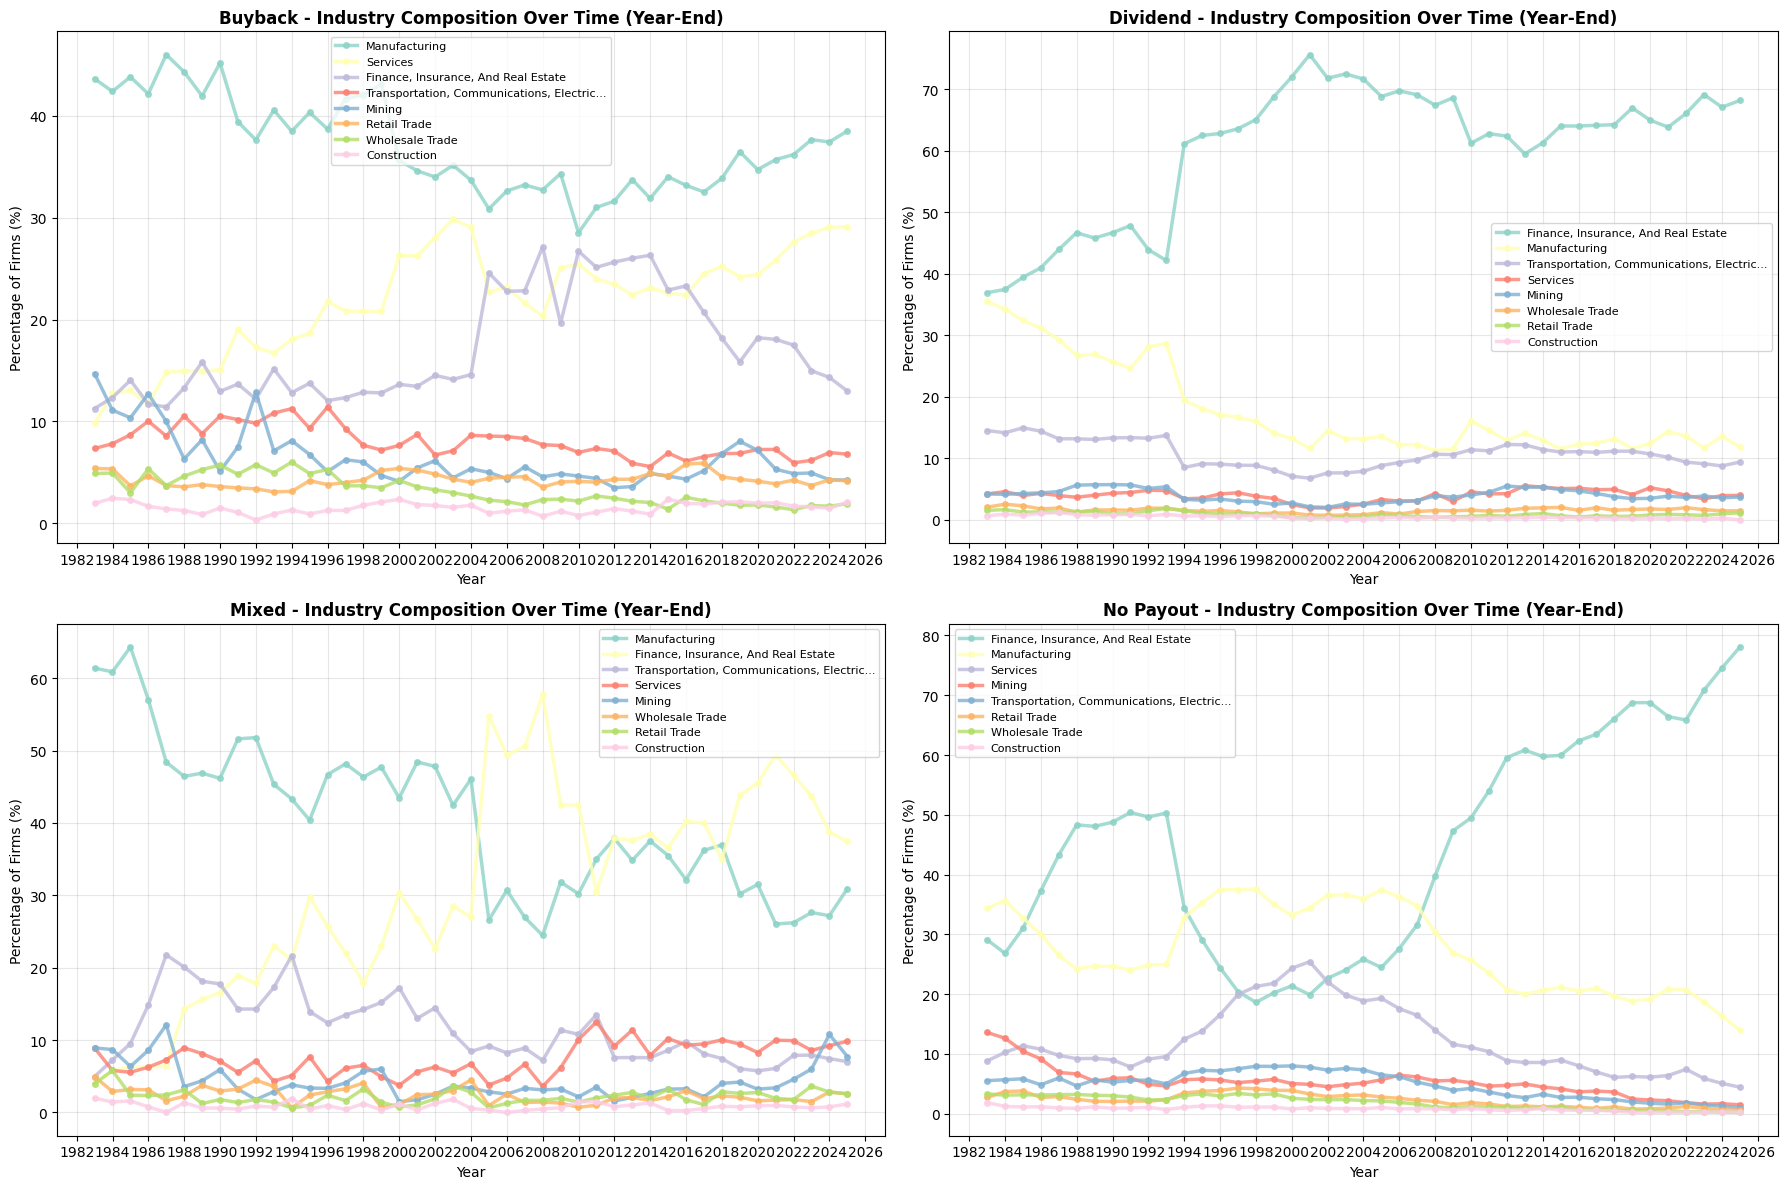


SIZE AND ROA EVOLUTION BY PAYOUT TYPE (WITH QUARTILES) - YEAR-END

Calculated quartiles for 172 year-payout type combinations
Years covered: 1982 to 2024

Displaying Graphs 4 & 5...



ValueError: 'yerr' must not contain negative values

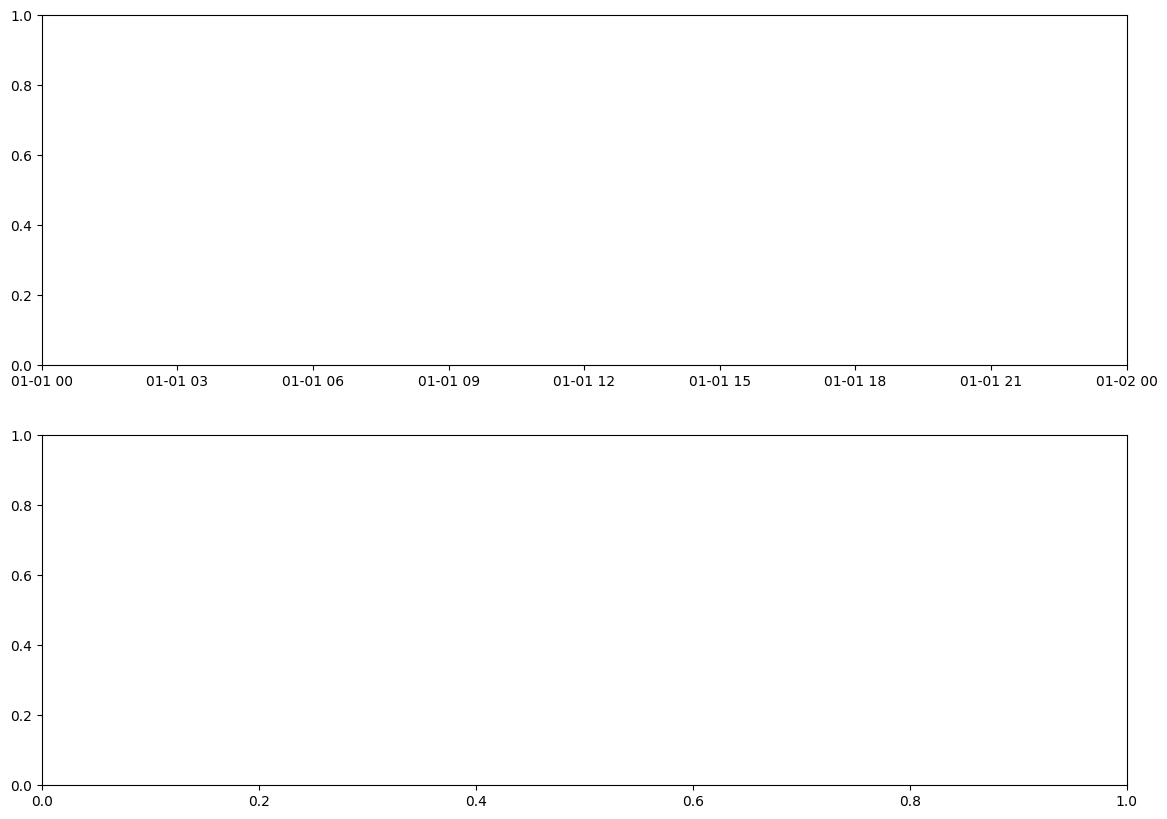

In [33]:
"""
Step 8: Summary Statistics by Payout Type (Overall and Time-Series)
Create comprehensive summary statistics for each payout type:
- Number of observations
- Number of unique firms (CUSIPs)
- Average market capitalization (firm size)
- Industry breakdown by SIC code categories
- Average return on assets (ROA)
"""

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Define payout order
payout_order = ["buyback", "dividend", "mixed", "no_payout"]

# ============================================================================
# SIC CODE TO INDUSTRY MAPPING
# ============================================================================

def map_sic_to_industry(sic_code):
    """
    Map SIC code to industry category based on standard classifications.
    Uses only the first 2 digits of the SIC code.
    
    Parameters:
    -----------
    sic_code : numeric
        Standard Industrial Classification code
    
    Returns:
    --------
    str : Industry category name
    """
    if pd.isna(sic_code):
        return "Unknown"
    
    try:
        # Convert to string to extract first 2 digits
        sic_str = str(int(sic_code))
        # Get first 2 digits, pad with zeros if needed
        if len(sic_str) >= 2:
            sic_2digit = int(sic_str[:2])
        else:
            # If less than 2 digits, pad with zero
            sic_2digit = int(sic_str.zfill(2)[:2])
    except:
        return "Unknown"
    
    # Map based on first 2 digits
    if 1 <= sic_2digit <= 9:
        return "Agriculture, Forestry, And Fishing"
    elif 10 <= sic_2digit <= 14:
        return "Mining"
    elif 15 <= sic_2digit <= 17:
        return "Construction"
    elif 20 <= sic_2digit <= 39:
        return "Manufacturing"
    elif 40 <= sic_2digit <= 49:
        return "Transportation, Communications, Electric, Gas, And Sanitary Services"
    elif 50 <= sic_2digit <= 51:
        return "Wholesale Trade"
    elif 52 <= sic_2digit <= 59:
        return "Retail Trade"
    elif 60 <= sic_2digit <= 67:
        return "Finance, Insurance, And Real Estate"
    elif 70 <= sic_2digit <= 89:
        return "Services"
    elif 90 <= sic_2digit <= 99:
        return "Public Administration"
    else:
        return "Unknown"

# Apply industry mapping to final_data
final_data["industry"] = final_data["sic"].apply(map_sic_to_industry)

# Industry order for consistent display
industry_order = [
    "Agriculture, Forestry, And Fishing",
    "Mining",
    "Construction",
    "Manufacturing",
    "Transportation, Communications, Electric, Gas, And Sanitary Services",
    "Wholesale Trade",
    "Retail Trade",
    "Finance, Insurance, And Real Estate",
    "Services",
    "Public Administration",
    "Unknown"
]

# ============================================================================
# PART 1: OVERALL SUMMARY STATISTICS
# ============================================================================

print("=" * 80)
print("PART 1: OVERALL SUMMARY STATISTICS BY PAYOUT TYPE")
print("=" * 80)

# Calculate overall summary statistics by payout type
summary_stats = final_data.groupby("payout_type").agg({
    "CUSIP": ["count", "nunique"],  # Number of observations and unique firms
    "market_cap": "mean",  # Average market cap
    "roa": "mean"  # Average return on assets
})

# Calculate industry breakdown (firms per industry category by payout type)
industry_firm_counts = final_data.groupby(["payout_type", "industry"])["CUSIP"].nunique().unstack(fill_value=0)
industry_firm_counts = industry_firm_counts.reindex(columns=industry_order, fill_value=0)
industry_firm_counts = industry_firm_counts.reindex(payout_order)

# Flatten multi-index column names
if isinstance(summary_stats.columns, pd.MultiIndex):
    summary_stats.columns = ["_".join(col).strip() for col in summary_stats.columns.values]
    # Rename to cleaner names
    summary_stats = summary_stats.rename(columns={
        "CUSIP_count": "n_observations",
        "CUSIP_nunique": "n_firms",
        "market_cap_mean": "avg_market_cap_millions",
        "roa_mean": "avg_roa_pct"
    })
else:
    # Fallback if columns are already flat
    summary_stats.columns = ["n_observations", "n_firms", "avg_market_cap_millions", "avg_roa_pct"]

# Format the summary statistics
summary_stats["avg_market_cap_millions"] = (summary_stats["avg_market_cap_millions"] / 1_000_000).round(2)
summary_stats["avg_roa_pct"] = (summary_stats["avg_roa_pct"] * 100).round(3)

# Reorder columns
summary_stats = summary_stats[[
    "n_observations",
    "n_firms",
    "avg_market_cap_millions",
    "avg_roa_pct"
]]

# Calculate percentages of total observations
total_obs = summary_stats["n_observations"].sum()
summary_stats["pct_of_total"] = (summary_stats["n_observations"] / total_obs * 100).round(2)

# Sort by payout type
summary_stats = summary_stats.reindex(payout_order)

# Display overall summary
print(f"\nTotal observations: {total_obs:,}")
print(f"Date range: {final_data['month'].min().strftime('%Y-%m')} to {final_data['month'].max().strftime('%Y-%m')}")
print(f"\n{'=' * 80}\n")
display(summary_stats)

# Formatted summary
print("\n" + "=" * 80)
print("FORMATTED SUMMARY BY PAYOUT TYPE (OVERALL)")
print("=" * 80)

for ptype in payout_order:
    if ptype in summary_stats.index:
        stats = summary_stats.loc[ptype]
        print(f"\n{ptype.upper().replace('_', ' ')}:")
        print(f"  • Number of observations: {stats['n_observations']:,} ({stats['pct_of_total']:.1f}% of total)")
        print(f"  • Number of unique firms: {stats['n_firms']:,}")
        print(f"  • Average market cap: ${stats['avg_market_cap_millions']:,.2f} million")
        print(f"  • Average ROA: {stats['avg_roa_pct']:.3f}%")

# Display industry breakdown
print("\n" + "=" * 80)
print("INDUSTRY BREAKDOWN BY PAYOUT TYPE (Number of Firms)")
print("=" * 80)
print("\nThis table shows how many unique firms (by CUSIP) fall into each SIC industry category:")
print("")
display(industry_firm_counts)

# Show industry breakdown in formatted way
print("\n" + "=" * 80)
print("INDUSTRY BREAKDOWN BY PAYOUT TYPE (Formatted)")
print("=" * 80)
for ptype in payout_order:
    if ptype in industry_firm_counts.index:
        print(f"\n{ptype.upper().replace('_', ' ')} - Firms by Industry:")
        industry_counts = industry_firm_counts.loc[ptype]
        for industry in industry_order:
            count = industry_counts[industry]
            if count > 0:
                print(f"  • {industry}: {count:,} firms")

# ============================================================================
# PART 2: TIME-SERIES SUMMARY (EVERY 6 MONTHS)
# ============================================================================

print("\n" + "=" * 80)
print("PART 2: TIME-SERIES SUMMARY BY PAYOUT TYPE (6-MONTH PERIODS)")
print("=" * 80)

# Create 6-month periods (ensure industry column exists)
final_data_copy = final_data.copy()
if "industry" not in final_data_copy.columns:
    final_data_copy["industry"] = final_data_copy["sic"].apply(map_sic_to_industry)
final_data_copy["year"] = final_data_copy["month"].dt.year
final_data_copy["month_num"] = final_data_copy["month"].dt.month
final_data_copy["period"] = final_data_copy["year"].astype(str) + "-" + (
    ((final_data_copy["month_num"] - 1) // 6) * 6 + 1
).astype(str).str.zfill(2)

# Sort periods chronologically
periods = sorted(final_data_copy["period"].unique())

print(f"\nTotal periods: {len(periods)}")
print(f"Period range: {periods[0]} to {periods[-1]}")
print(f"\n{'=' * 80}\n")

# Calculate summary statistics for each 6-month period and payout type
time_summary_list = []

for period in periods:
    period_data = final_data_copy[final_data_copy["period"] == period]
    
    if len(period_data) == 0:
        continue
    
    period_stats = period_data.groupby("payout_type").agg({
        "CUSIP": ["count", "nunique"],
        "market_cap": "mean",
        "roa": "mean"
    })
    
    # Flatten multi-index column names
    if isinstance(period_stats.columns, pd.MultiIndex):
        period_stats.columns = ["_".join(col).strip() for col in period_stats.columns.values]
        # Rename to cleaner names
        period_stats = period_stats.rename(columns={
            "CUSIP_count": "n_observations",
            "CUSIP_nunique": "n_firms",
            "market_cap_mean": "avg_market_cap_millions",
            "roa_mean": "avg_roa_pct"
        })
    else:
        period_stats.columns = ["n_observations", "n_firms", "avg_market_cap_millions", "avg_roa_pct"]
    
    # Format
    period_stats["avg_market_cap_millions"] = (period_stats["avg_market_cap_millions"] / 1_000_000).round(2)
    period_stats["avg_roa_pct"] = (period_stats["avg_roa_pct"] * 100).round(3)
    
    # Add period column
    period_stats["period"] = period
    
    # Calculate percentage of total for this period
    period_total = period_stats["n_observations"].sum()
    period_stats["pct_of_total"] = (period_stats["n_observations"] / period_total * 100).round(2)
    
    # Reorder columns and reindex
    period_stats = period_stats[[
        "period",
        "n_observations",
        "n_firms",
        "avg_market_cap_millions",
        "avg_roa_pct",
        "pct_of_total"
    ]]
    
    # Reindex to include all payout types (fill missing with 0)
    period_stats = period_stats.reindex(payout_order)
    period_stats["period"] = period
    
    time_summary_list.append(period_stats)

# Combine all periods
time_summary = pd.concat(time_summary_list)

# Reset index to make payout_type a column
time_summary = time_summary.reset_index()
time_summary = time_summary.rename(columns={"index": "payout_type"})

# Display time series summary
print("TIME-SERIES SUMMARY BY PERIOD AND PAYOUT TYPE")
print("=" * 80)
display(time_summary)

# Formatted time series summary (show a sample of periods)
print("\n" + "=" * 80)
print("FORMATTED TIME-SERIES SUMMARY (SAMPLE - EVERY 10 PERIODS)")
print("=" * 80)

# Show every 10th period to keep output manageable
sample_periods = periods[::10] if len(periods) > 20 else periods

for period in sample_periods:
    period_data = time_summary[time_summary["period"] == period]
    if len(period_data) > 0:
        print(f"\n{'=' * 80}")
        print(f"PERIOD: {period}")
        print(f"{'=' * 80}")
        for _, row in period_data.iterrows():
            if pd.notna(row["n_observations"]):
                print(f"\n{row['payout_type'].upper().replace('_', ' ')}:")
                print(f"  • Observations: {row['n_observations']:.0f} ({row['pct_of_total']:.1f}% of period)")
                print(f"  • Unique firms: {row['n_firms']:.0f}")
                print(f"  • Avg market cap: ${row['avg_market_cap_millions']:,.2f}M")
                print(f"  • Avg ROA: {row['avg_roa_pct']:.3f}%")

# ============================================================================
# PART 3: VISUALIZATION - PAYOUT TYPE EVOLUTION OVER TIME
# ============================================================================

print("\n" + "=" * 80)
print("PART 3: VISUALIZATIONS - PAYOUT TYPE EVOLUTION OVER TIME")
print("=" * 80)

# Use year-end data for smoother visualization
# Filter for December (month 12) - year-end values
yearend_data = final_data[final_data["month"].dt.month == 12].copy()

# Calculate year-end percentages
yearend_pct = yearend_data.groupby(["month", "payout_type"]).size().unstack(fill_value=0)
yearend_pct_pct = yearend_pct.div(yearend_pct.sum(axis=1), axis=0) * 100

# Ensure all payout types are present
for ptype in payout_order:
    if ptype not in yearend_pct_pct.columns:
        yearend_pct_pct[ptype] = 0

# Reorder columns
yearend_pct_pct = yearend_pct_pct[payout_order]

colors = {"buyback": "#2E86AB", "dividend": "#A23B72", "mixed": "#F18F01", "no_payout": "#C73E1D"}

# ============================================================================
# Graph 1 & 2: Payout Type Evolution (Year-End Data)
# ============================================================================

fig1, axes1 = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Stacked area chart (year-end)
ax1 = axes1[0]
ax1.stackplot(yearend_pct_pct.index, 
              yearend_pct_pct["buyback"], 
              yearend_pct_pct["dividend"], 
              yearend_pct_pct["mixed"], 
              yearend_pct_pct["no_payout"],
              labels=["Buyback", "Dividend", "Mixed", "No Payout"],
              colors=[colors["buyback"], colors["dividend"], colors["mixed"], colors["no_payout"]],
              alpha=0.7)
ax1.set_ylabel("Percentage of Observations (%)", fontsize=12)
ax1.set_title("Evolution of Payout Types Over Time (Stacked Area Chart - Year-End)", fontsize=14, fontweight="bold")
ax1.legend(loc="upper left", frameon=True)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 100)

# Format x-axis
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_minor_locator(mdates.YearLocator())

# Plot 2: Line chart (year-end - smooth)
ax2 = axes1[1]
for ptype in payout_order:
    ax2.plot(yearend_pct_pct.index, yearend_pct_pct[ptype], 
             label=ptype.replace("_", " ").title(), 
             color=colors[ptype], 
             linewidth=2.5, 
             marker="o",
             markersize=5,
             alpha=0.8)
ax2.set_ylabel("Percentage of Observations (%)", fontsize=12)
ax2.set_xlabel("Year", fontsize=12)
ax2.set_title("Evolution of Payout Types Over Time (Line Chart - Year-End)", fontsize=14, fontweight="bold")
ax2.legend(loc="best", frameon=True)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 100)

# Format x-axis
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_minor_locator(mdates.YearLocator())

plt.tight_layout()
plt.show()

# ============================================================================
# Graph 3: Industry Evolution for Each Payout Type
# ============================================================================

print("\n" + "=" * 80)
print("INDUSTRY EVOLUTION BY PAYOUT TYPE")
print("=" * 80)

# Calculate year-end industry percentages for each payout type
fig2, axes2 = plt.subplots(2, 2, figsize=(18, 12))
axes2 = axes2.flatten()

for idx, ptype in enumerate(payout_order):
    ax = axes2[idx]
    
    # Filter data for this payout type (year-end only)
    ptype_data = yearend_data[yearend_data["payout_type"] == ptype]
    
    # Calculate year-end industry percentages
    yearend_ind = ptype_data.groupby(["month", "industry"]).size().unstack(fill_value=0)
    yearend_ind_pct = yearend_ind.div(yearend_ind.sum(axis=1), axis=0) * 100
    
    # Plot top industries (or all if manageable)
    # Sort by average percentage across all years
    ind_avg = yearend_ind_pct.mean().sort_values(ascending=False)
    top_industries = ind_avg.head(8).index.tolist()  # Top 8 industries
    
    # Create color map for industries
    industry_colors = plt.cm.Set3(range(len(top_industries)))
    
    for ind_idx, industry in enumerate(top_industries):
        if industry in yearend_ind_pct.columns:
            ax.plot(yearend_ind_pct.index, yearend_ind_pct[industry], 
                   label=industry[:40] + "..." if len(industry) > 40 else industry,
                   color=industry_colors[ind_idx],
                   linewidth=2.5,
                   marker="o",
                   markersize=4,
                   alpha=0.8)
    
    ax.set_ylabel("Percentage of Firms (%)", fontsize=10)
    ax.set_xlabel("Year", fontsize=10)
    ax.set_title(f"{ptype.replace('_', ' ').title()} - Industry Composition Over Time (Year-End)", 
                fontsize=12, fontweight="bold")
    ax.legend(loc="best", frameon=True, fontsize=8, ncol=1)
    ax.grid(True, alpha=0.3)
    
    # Format x-axis
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

# ============================================================================
# Graph 4 & 5: Size (Market Cap) and ROA Over Time with Quartiles
# ============================================================================

print("\n" + "=" * 80)
print("SIZE AND ROA EVOLUTION BY PAYOUT TYPE (WITH QUARTILES) - YEAR-END")
print("=" * 80)

# Use year-end data for quartile calculations
# Get unique years from year-end data
years = sorted(yearend_data["month"].dt.year.unique())

# Calculate quartiles for market cap and ROA by year and payout type
size_data = []
roa_data = []

for year in years:
    year_data = yearend_data[yearend_data["month"].dt.year == year]
    
    for ptype in payout_order:
        ptype_year_data = year_data[year_data["payout_type"] == ptype]
        
        if len(ptype_year_data) > 0:
            # Market cap stats
            mcap_mean = ptype_year_data["market_cap"].mean() / 1_000_000  # in millions
            mcap_q25 = ptype_year_data["market_cap"].quantile(0.25) / 1_000_000
            mcap_q75 = ptype_year_data["market_cap"].quantile(0.75) / 1_000_000
            
            # ROA stats
            roa_mean = ptype_year_data["roa"].mean() * 100  # as percentage
            roa_q25 = ptype_year_data["roa"].quantile(0.25) * 100
            roa_q75 = ptype_year_data["roa"].quantile(0.75) * 100
            
            year_date = pd.to_datetime(f"{year}-12-31", format="%Y-%m-%d")
            
            size_data.append({
                "period": year_date,
                "payout_type": ptype,
                "mean": mcap_mean,
                "q25": mcap_q25,
                "q75": mcap_q75
            })
            
            roa_data.append({
                "period": year_date,
                "payout_type": ptype,
                "mean": roa_mean,
                "q25": roa_q25,
                "q75": roa_q75
            })

size_df = pd.DataFrame(size_data)
roa_df = pd.DataFrame(roa_data)

print(f"\nCalculated quartiles for {len(size_df)} year-payout type combinations")
print(f"Years covered: {years[0]} to {years[-1]}")
print(f"\nDisplaying Graphs 4 & 5...\n")

# Create visualizations
fig3, axes3 = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Market Cap over time with quartiles
ax1 = axes3[0]
for ptype in payout_order:
    ptype_data = size_df[size_df["payout_type"] == ptype].sort_values("period")
    if len(ptype_data) > 0:
        # Error bars (quartiles)
        yerr_lower = ptype_data["mean"] - ptype_data["q25"]
        yerr_upper = ptype_data["q75"] - ptype_data["mean"]
        yerr = [yerr_lower.values, yerr_upper.values]
        
        ax1.errorbar(ptype_data["period"], ptype_data["mean"],
                    yerr=yerr,
                    label=ptype.replace("_", " ").title(),
                    color=colors[ptype],
                    linewidth=2.5,
                    marker="o",
                    markersize=5,
                    capsize=4,
                    capthick=2,
                    alpha=0.8,
                    elinewidth=1.5)

ax1.set_ylabel("Market Cap (Millions USD)", fontsize=12)
ax1.set_xlabel("Year", fontsize=12)
ax1.set_title("Average Market Cap Over Time by Payout Type (Mean ± Quartiles) - Year-End", 
              fontsize=14, fontweight="bold")
ax1.legend(loc="best", frameon=True)
ax1.grid(True, alpha=0.3)
ax1.set_yscale("log")  # Use log scale for better visualization of wide ranges

# Format x-axis
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_minor_locator(mdates.YearLocator())

# Plot 2: ROA over time with quartiles
ax2 = axes3[1]
for ptype in payout_order:
    ptype_data = roa_df[roa_df["payout_type"] == ptype].sort_values("period")
    if len(ptype_data) > 0:
        # Error bars (quartiles)
        yerr_lower = ptype_data["mean"] - ptype_data["q25"]
        yerr_upper = ptype_data["q75"] - ptype_data["mean"]
        yerr = [yerr_lower.values, yerr_upper.values]
        
        ax2.errorbar(ptype_data["period"], ptype_data["mean"],
                    yerr=yerr,
                    label=ptype.replace("_", " ").title(),
                    color=colors[ptype],
                    linewidth=2.5,
                    marker="o",
                    markersize=5,
                    capsize=4,
                    capthick=2,
                    alpha=0.8,
                    elinewidth=1.5)

ax2.set_ylabel("Return on Assets (ROA, %)", fontsize=12)
ax2.set_xlabel("Year", fontsize=12)
ax2.set_title("Average ROA Over Time by Payout Type (Mean ± Quartiles) - Year-End", 
              fontsize=14, fontweight="bold")
ax2.legend(loc="best", frameon=True)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color="black", linestyle="--", linewidth=0.5, alpha=0.5)

# Format x-axis
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_minor_locator(mdates.YearLocator())

plt.tight_layout()
plt.show()

# Display summary statistics
print("\nSummary Statistics from Visualizations:")
print(f"Average percentage by payout type over all year-end periods:")
for ptype in payout_order:
    avg_pct = yearend_pct_pct[ptype].mean()
    print(f"  • {ptype.replace('_', ' ').title()}: {avg_pct:.2f}%")

print("\n" + "=" * 80)
print("Summary dataframes saved:")
print("  - 'summary_stats': Overall summary by payout type")
print("  - 'time_summary': Time-series summary (6-month periods)")
print("  - 'industry_firm_counts': Number of firms by payout type and industry")
print("=" * 80)
